## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pc_algorithm import (
    run_pc_algorithm, 
    compare_with_baseline, 
    comparison,
    visualize_pc_graph
)

# Plotting configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
data = pd.read_csv('TFM_dataset.csv')

# Fill missing BMI values with mode
bmi_mode = data['bmi'].mode()[0]
data['bmi'] = data['bmi'].fillna(bmi_mode)

if 'randid' in data.columns:
    data = data.drop('randid', axis=1)

data.head()

,age,bmi,cardiac ischemia,diabetes mellitus,diastolic pressure,major acute cardiovascular event,systolic pressure
0,39,27.0,1,0,70,1,106
1,46,28.7,0,0,81,0,121
2,48,25.3,0,0,80,0,128
3,61,28.6,0,0,95,1,150
4,46,23.1,0,0,84,0,130


In [3]:
data.describe()

,age,bmi,cardiac ischemia,diabetes mellitus,diastolic pressure,major acute cardiovascular event,systolic pressure
count,4434.000000,4415.000000,4434.000000,4434.000000,4434.000000,4434.000000,4434.000000
mean,49.925801,25.851348,0.164862,0.027289,83.164186,0.260938,133.004736
std,8.676929,4.102144,0.371098,0.162943,12.051439,0.439196,22.419794
min,32.000000,15.500000,0.000000,0.000000,48.000000,0.000000,84.000000
25%,42.000000,23.100000,0.000000,0.000000,75.000000,0.000000,118.000000
50%,49.000000,25.500000,0.000000,0.000000,82.000000,0.000000,129.000000
75%,57.000000,28.100000,0.000000,0.000000,90.000000,1.000000,144.000000
max,70.000000,56.800000,1.000000,1.000000,143.000000,1.000000,295.000000


## 2. Define LLM Baseline Graph

This is the ground truth graph extracted from LLM-based causal discovery using medical literature and domain knowledge.

In [7]:
# LLM Baseline graph from causal_relationships_rag.json
baseline_graph = {
    ('age', 'bmi'): 1,
    ('age', 'systolic pressure'): 1,
    ('age', 'diastolic pressure'): 1,
    ('age', 'cardiac ischemia'): 1,
    ('age', 'diabetes mellitus'): 1,
    ('age', 'major acute cardiovascular event'): 1,
    ('bmi', 'systolic pressure'): 1,
    ('bmi', 'diastolic pressure'): 1,
    ('bmi', 'cardiac ischemia'): 1,
    ('bmi', 'diabetes mellitus'): 1,
    ('bmi', 'major acute cardiovascular event'): 1,
    ('systolic pressure', 'cardiac ischemia'): 1,
    ('systolic pressure', 'major acute cardiovascular event'): 1,
    ('diastolic pressure', 'cardiac ischemia'): 1,
    ('diastolic pressure', 'major acute cardiovascular event'): 1,
    ('diabetes mellitus', 'systolic pressure'): 1,
    ('diabetes mellitus', 'diastolic pressure'): 1,
    ('diabetes mellitus', 'cardiac ischemia'): 1,
    ('diabetes mellitus', 'major acute cardiovascular event'): 1,
    ('cardiac ischemia', 'major acute cardiovascular event'): 1,
}

for edge in sorted(baseline_graph.keys()):
    print(f"  {edge[0]} → {edge[1]}")

  age → bmi
  age → cardiac ischemia
  age → diabetes mellitus
  age → diastolic pressure
  age → major acute cardiovascular event
  age → systolic pressure
  bmi → cardiac ischemia
  bmi → diabetes mellitus
  bmi → diastolic pressure
  bmi → major acute cardiovascular event
  bmi → systolic pressure
  cardiac ischemia → major acute cardiovascular event
  diabetes mellitus → cardiac ischemia
  diabetes mellitus → diastolic pressure
  diabetes mellitus → major acute cardiovascular event
  diabetes mellitus → systolic pressure
  diastolic pressure → cardiac ischemia
  diastolic pressure → major acute cardiovascular event
  systolic pressure → cardiac ischemia
  systolic pressure → major acute cardiovascular event


## 3. Run PC Algorithm

The PC (Peter-Clark) algorithm is a constraint-based method that:
1. Starts with a fully connected graph
2. Tests conditional independencies in the data
3. Removes edges based on statistical tests
4. Orients edges using collider detection

In [4]:
# Run PC algorithm with default parameters
pc_results = run_pc_algorithm(
    data=data,
    alpha=0.05,           # Significance level (5%)
    ci_test='chi_square', # Chi-square test for discrete/binary variables
    max_cond_vars=3,      # Maximum conditioning set size
    return_type='both'
)

print(f"\nPC Algorithm Results:")
print(f"  Estimated edges: {pc_results['n_edges']}")
print(f"  Variables: {len(pc_results['variables'])}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'bmi': 'N', 'cardiac ischemia': 'N', 'diabetes mellitus': 'N', 'diastolic pressure': 'N', 'major acute cardiovascular event': 'N', 'systolic pressure': 'N'}


  0%|          | 0/5 [00:00<?, ?it/s]


PC Algorithm Results:
  Estimated edges: 5
  Variables: 7


In [5]:
# Display PC algorithm estimated edges
for edge in sorted(pc_results['edge_dict'].keys()):
    print(f"  {edge[0]} → {edge[1]}")

  age → systolic pressure
  cardiac ischemia → bmi
  diastolic pressure → bmi
  major acute cardiovascular event → age
  systolic pressure → diastolic pressure


## 4. Visualize PC Algorithm Graph

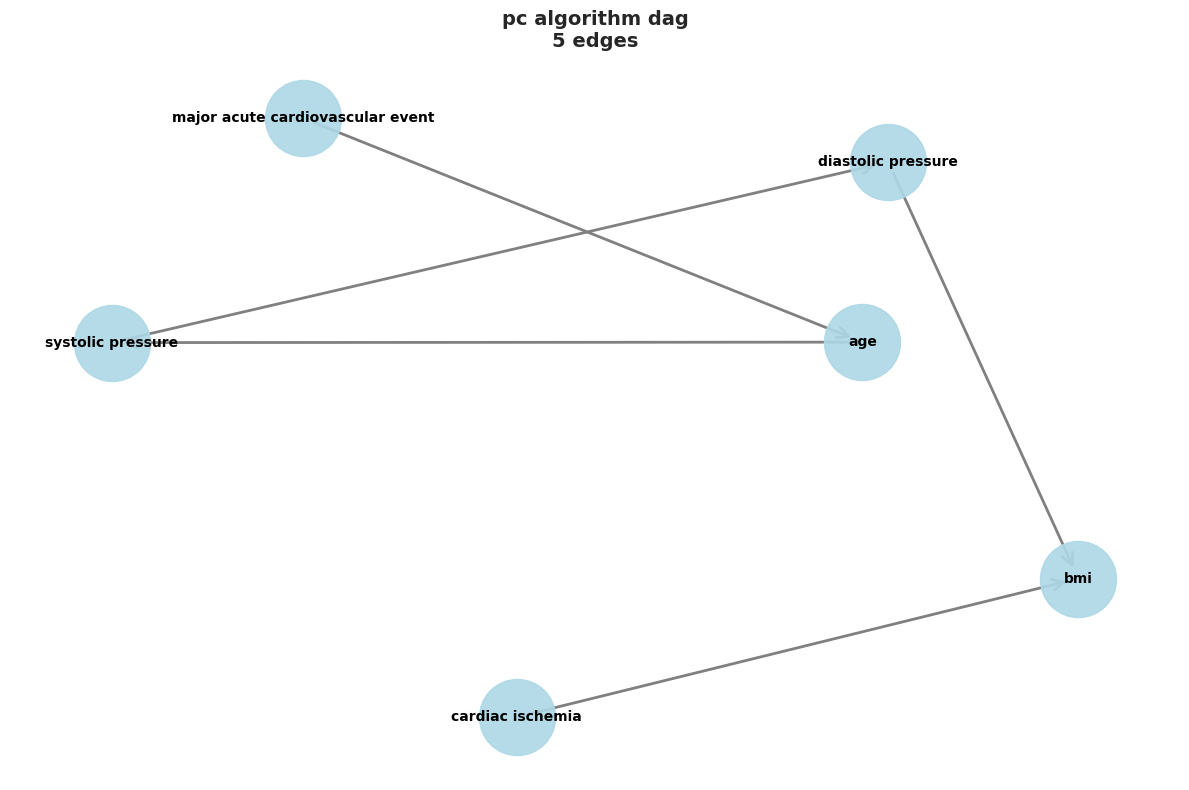

In [10]:
# Visualize PC algorithm DAG
visualize_pc_graph(pc_results, save_path='pc_algorithm_dag.png')

In [7]:
import json

# Save PC algorithm graph in the same format as baseline_graph.json
pc_graph_data = {
    'adjacency_matrix': pc_results['adjacency_matrix'].tolist(),
    'variables': pc_results['variables']
}

with open('pc_estimated_graph.json', 'w', encoding='utf-8') as f:
    json.dump(pc_graph_data, f, indent=2)

print(f"  variables: {len(pc_graph_data['variables'])}")
print(f"  edges: {pc_results['n_edges']}")

  variables: 7
  edges: 5


In [6]:
pc_results['adjacency_matrix']

array([[0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.]])

## 6. Compare PC Algorithm with LLM Baseline